In [1]:
import duckdb

conn = duckdb.connect()

# Path disesuaikan dengan folder sub-ekstrak 'gen z dataset'
query = """
SELECT * 
FROM '../data/raw/gen z dataset/genz_social_media_usage_1M.csv' 
LIMIT 5
"""

df_preview = conn.execute(query).df()
df_preview

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [2]:
# Buat file parquet untuk efisiensi I/O ke depannya
parquet_path = "../data/raw/genz_social_media_usage_1M.parquet"

conn.execute(f"""
    COPY (
        SELECT * 
        FROM '../data/raw/gen z dataset/genz_social_media_usage_1M.csv'
    ) 
    TO '{parquet_path}' (FORMAT PARQUET)
""")

print("Konversi ke Parquet selesai!")

Konversi ke Parquet selesai!


In [3]:
# Cek total baris dan deteksi nilai NULL di seluruh kolom
null_check_query = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(age) AS null_age,
    COUNT(*) - COUNT(daily_usage_hours) AS null_daily_hours,
    COUNT(*) - COUNT(avg_session_minutes) AS null_avg_session,
    COUNT(*) - COUNT(screen_time_before_sleep) AS null_screen_time_sleep,
    COUNT(*) - COUNT(mental_health_score) AS null_mental_score
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""

conn.execute(null_check_query).df()

,total_rows,null_age,null_daily_hours,null_avg_session,null_screen_time_sleep,null_mental_score
0,1000000,0,0,0,0,0


In [4]:
stats_query = """
SELECT 
    ROUND(AVG(daily_usage_hours), 2) AS avg_daily_hours,
    MIN(daily_usage_hours) AS min_daily_hours,
    MAX(daily_usage_hours) AS max_daily_hours,
    ROUND(AVG(avg_session_minutes), 2) AS avg_session_min,
    MIN(avg_session_minutes) AS min_session_min,
    MAX(avg_session_minutes) AS max_session_min,
    ROUND(AVG(screen_time_before_sleep), 2) AS avg_sleep_screentime,
    ROUND(AVG(num_platforms_used), 2) AS avg_platforms,
    ROUND(AVG(night_usage) * 100, 2) AS pct_night_users
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""

df_stats = conn.execute(stats_query).df()
df_stats

,avg_daily_hours,min_daily_hours,max_daily_hours,avg_session_min,min_session_min,max_session_min,avg_sleep_screentime,avg_platforms,pct_night_users
0,3.51,0.5,10.0,25.09,5.0,80.262224,40.12,3.0,60.0


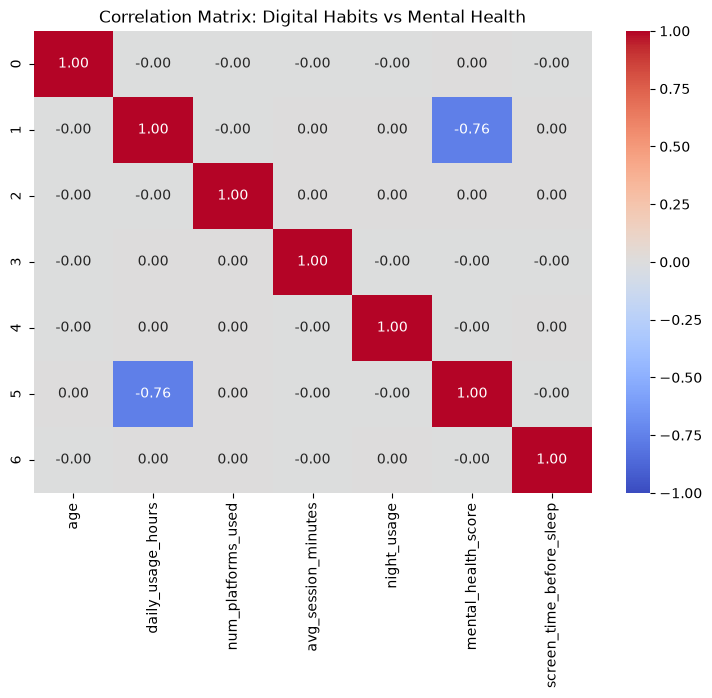

In [5]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Muat data numerik ke DataFrame Polars
numeric_cols = [
    'age', 'daily_usage_hours', 'num_platforms_used', 
    'avg_session_minutes', 'night_usage', 'mental_health_score', 
    'screen_time_before_sleep'
]

df = pl.read_parquet('../data/raw/genz_social_media_usage_1M.parquet', columns=numeric_cols)

# Hitung korelasi Pearson
corr_matrix = df.corr()

# Visualisasikan Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix.to_pandas(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix: Digital Habits vs Mental Health")
plt.show()

In [6]:
feature_query = """
SELECT 
    daily_usage_hours,
    avg_session_minutes,
    num_platforms_used,
    night_usage,
    screen_time_before_sleep,
    ROUND((daily_usage_hours * 60) / NULLIF(avg_session_minutes, 0), 2) AS session_frequency,
    ROUND((screen_time_before_sleep / NULLIF(daily_usage_hours * 60, 0)) * 100, 2) AS night_sleep_ratio,
    mental_health_score,
    addiction_level,
    age,
    country
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""

df_features = conn.execute(feature_query).df()
df_features.head()

,daily_usage_hours,avg_session_minutes,num_platforms_used,night_usage,screen_time_before_sleep,session_frequency,night_sleep_ratio,mental_health_score,addiction_level,age,country
0,2.658617,29.222443,4,0,15.779443,5.46,9.89,6.705830,Medium,19,Australia
1,5.685387,32.464726,3,1,47.714864,10.51,13.99,6.633111,High,16,USA
2,2.782420,18.170204,2,1,62.524625,9.19,37.45,6.035397,Medium,25,India
3,3.486598,22.493804,4,1,31.935102,9.30,15.27,8.110861,Medium,27,India
4,3.748829,27.358410,1,1,29.466046,8.22,13.10,6.658598,Medium,23,India


In [7]:
from sklearn.preprocessing import StandardScaler

# Fitur murni perilaku
clustering_features = [
    'daily_usage_hours',
    'avg_session_minutes',
    'num_platforms_used',
    'night_usage',
    'screen_time_before_sleep',
    'session_frequency',
    'night_sleep_ratio'
]

# Normalisasi data numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[clustering_features])